## Getting familiar with REBOUND

Links that helped me get started:

-  https://github.com/trentdupuy/PHYS10111_REBOUND/blob/main/rebound_HR8799.ipynb. 

- https://www.youtube.com/watch?v=S2N6DXSpkv8&ab_channel=Nora%27sGuidetotheGalaxy 

- https://www.youtube.com/@reboundcode

In [1]:
#%matplotlib notebook
#%matplotlib widget
import numpy as np
import rebound
from matplotlib import pyplot as plt
from IPython import display
import pandas as pd
import astropy.constants as const

Start the simulation and define units:

In [2]:
sim = rebound.Simulation()
#sim.G = 39.476926408897626 

sim.units = ['msun', 'yr', 'AU']

print("G = {0}.".format(sim.G))

print(sim.units)

G = 39.476926421373.
{'length': 'au', 'mass': 'msun', 'time': 'yr'}


### Orbital parameters:

| Object   |    Mass    | a  (au)  |  e | omega (deg) | inc (deg) |
| :------: | :------:    | :-----:  | :-----: | :-----: | :-----: |
| PDS 70   | $0.76±0.02$ $M_\odot$ | -- | -- | -- | -- |
| PDS 70 b | $3 ± 1 M_{Jup}$     | $20 ± 2 $ | $0.19^{+0.15}_{-0.09}$ | $148 ± 31$ |$ 140^{+ 7}_{-6}$ |
| PDS 70 c | $2 ± 1$   $M_{Jup}$   | $34^{+6}_{-3}$ |$ 0.11^{+0.12}_{-0.06}$ | $ 136^{+50}_{- 58}$ | $132 ± 7$ |

## Test 1
Start by using normal vals.

In [3]:
dtor = np.pi/180 #degree to radian
jtos = 0.000954265748  #jupiter mass to solar mass

sim.add(m = 0.76)
sim.add(m = 3*jtos, a = 20, omega = 148*dtor, e = 0.19, inc = 140*dtor)
sim.add(m = 2*jtos, a = 34, omega = 136*dtor, e = 0.11, inc = 132*dtor)
sim.save_to_file("start.bin")
sim.status()

---------------------------------
REBOUND version:     	4.5.0
REBOUND built on:    	Jan  2 2026 22:14:56
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x780f475961d0, m=0.76 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x780f475959d0, m=0.002862797244 x=-13.7383791577341 y=-6.576255664214211 z=5.518133702369647 vx=-0.7881712067851825 vy=0.9662406570898352 vz=-0.8107721789925737>
<rebound.particle.Particle object at 0x780f475961d0, m=0.001908531496 x=-21.818778410177075 y=-14.090046497136024 z=15.641881380531032 vx=-0.7339887247553009 vy=0.5101610356423244 vz=-0.5656067212782884>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 3.947693e+01
N:
< 0
---
> 3
python_unit_l:
< 0
---
> 12937928
python_unit_m:
< 0
---
> 2145773914
python_unit_t:
< 0
---
> 18

In [4]:
#del sim
sim = rebound.Simulation('start.bin')
sim.status()
sim.orbits()

---------------------------------
REBOUND version:     	4.5.0
REBOUND built on:    	Jan  2 2026 22:14:56
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x780f47594cd0, m=0.76 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x780f47595b50, m=0.002862797244 x=-13.7383791577341 y=-6.576255664214211 z=5.518133702369647 vx=-0.7881712067851825 vy=0.9662406570898352 vz=-0.8107721789925737>
<rebound.particle.Particle object at 0x780f47594cd0, m=0.001908531496 x=-21.818778410177075 y=-14.090046497136024 z=15.641881380531032 vx=-0.7339887247553009 vy=0.5101610356423244 vz=-0.5656067212782884>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 3.947693e+01
N:
< 0
---
> 3
python_unit_l:
< 0
---
> 12937928
python_unit_m:
< 0
---
> 2145773914
python_unit_t:
< 0
---
> 18

[<rebound.Orbit instance, a=19.999999999999993 e=0.1899999999999998 inc=2.443460952792061 Omega=0.0 omega=2.5830872929516087 f=6.283185307179585>,
 <rebound.Orbit instance, a=33.999999999999986 e=0.1099999999999998 inc=2.303834612632515 Omega=0.0 omega=2.373647782712288 f=0.0>]

In [5]:
sim.move_to_com() #move to COM frame

In [6]:
# print("      a (au)          e       omega (deg)  inc (deg)    Omega (deg)     P (yr) ")
# for o in sim.orbits(): 
#     print("%12.4f %12.4f %12.4f %12.4f %12.4f %13.4f " % (o.a, o.e, o.omega/dtor, o.inc/dtor, o.Omega/dtor, o.P))

d = {'Particles': ['PDS 70 b', 'PDS 70 c'],
     'a (au)': [round(o.a, 3) for o in sim.orbits()],
     'e': [round(o.e, 3) for o in sim.orbits()],
     'omega(deg)': [round(o.omega/dtor, 3) for o in sim.orbits()],
     'i (deg)': [round(o.inc/dtor, 3) for o in sim.orbits()],
     'Omega (deg)': [round(o.omega/dtor, 3) for o in sim.orbits()],
     'P (yr)': [round(o.P, 3) for o in sim.orbits()] }

initial_conditions = pd.DataFrame(d)

initial_conditions

,Particles,a (au),e,omega(deg),i (deg),Omega (deg),P (yr)
0,PDS 70 b,20.0,0.19,148.0,140.0,148.0,102.407
1,PDS 70 c,34.0,0.11,136.0,132.0,136.0,226.705


## Plot of initial conditions

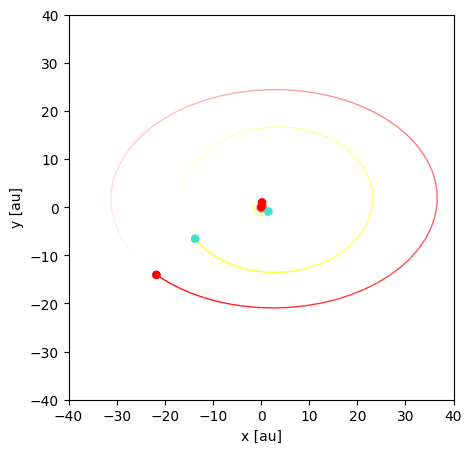

In [21]:
op = rebound.OrbitPlot(sim, color=['red','yellow'], unitlabel="[au]", )
op.primary.set_color("orange")
op.particles.set_color(["red", "turquoise"])

ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)
plt.show()

In [9]:
#rebound.OrbitPlotSet(sim)

In [15]:
sim.integrate(1e4)

In [17]:
sim.dt = 0.8
nframe = 220        # at home, I found that frames render at a rate of 10 per second
framestep = sim.dt  

fig = op.fig
for i in range(nframe):
    op.sim.integrate(sim.t + framestep*2) # timestep the sim
    display.display(plt.gcf())          # start to...
    display.clear_output(wait=True)     # ...clean up old plot
    op.update() 

AttributeError: 'function' object has no attribute 'display'

In [25]:
d2 = {'Particles': ['PDS 70 b', 'PDS 70 c'],
     'a (au)': [round(o.a, 3) for o in sim.orbits()],
     'e': [round(o.e, 3) for o in sim.orbits()],
     'omega(deg)': [round(o.omega/dtor, 3) for o in sim.orbits()],
     'i (deg)': [round(o.inc/dtor, 3) for o in sim.orbits()],
     'Omega (deg)': [round(o.omega/dtor, 3) for o in sim.orbits()],
     'P (yr)': [round(o.P, 3) for o in sim.orbits()] }

after_1e3_yrs = pd.DataFrame(d2)

In [28]:
print("      a (au)          e       omega (deg)  inc (deg)    Omega (deg)     P (yr) ")
for o in sim.orbits(): 
    print("%12.4f %12.4f %12.4f %12.4f %12.4f %13.4f " % (o.a, o.e, o.omega/dtor, o.inc/dtor, o.Omega/dtor, o.P))

initial_conditions, after_1e3_yrs

      a (au)          e       omega (deg)  inc (deg)    Omega (deg)     P (yr) 
     15.2441       0.5297     192.7759     141.2268       0.5631       68.1458 
    160.6303       0.8112      53.2376     132.9250      -0.3220     2328.0033 


(  Particles  a (au)     e  omega(deg)  i (deg)  Omega (deg)   P (yr)
 0  PDS 70 b    20.0  0.19       148.0    140.0        148.0  102.407
 1  PDS 70 c    34.0  0.11       136.0    132.0        136.0  226.705,
   Particles  a (au)      e  omega(deg)  i (deg)  Omega (deg)   P (yr)
 0  PDS 70 b  19.923  0.185     158.613  140.029      158.613  101.817
 1  PDS 70 c  34.158  0.120     131.944  131.972      131.944  228.291)

In [26]:
sim.dt = 0.1
sim.integrate(1e6, exact_finish_time=0)
sim.t

5000002.3005431825

---------------------------------
REBOUND version:     	4.5.0
REBOUND built on:    	Jan  2 2026 22:14:56
Number of particles: 	6
Selected integrator: 	ias15
Simulation time:     	1.0003200000000001e+04
Current timestep:    	0.025937
---------------------------------
<rebound.particle.Particle object at 0x72dab5711a50, m=1.0 x=0.04489952759857137 y=0.02537727950641512 z=-0.025832886994638735 vx=0.008469916840644328 vy=-0.006260605065905377 vz=0.002924508183906085>
<rebound.particle.Particle object at 0x72dab4bb54d0, m=0.001 x=0.21627273048397713 y=0.9808476354318291 z=-0.025832886994638735 vx=-6.373051781517851 vy=1.0321653475676618 vz=0.002924508183906085>
<rebound.particle.Particle object at 0x72dab5711a50, m=0.0005 x=1.5295464498236315 y=-0.9013551462662167 z=-0.025832886994638735 vx=2.106476149368792 vy=4.014950982776913 vz=0.002924508183906085>
<rebound.particle.Particle object at 0x72dab4bb54d0, m=0.76 x=0.04581185577016633 y=0.025868646598405473 z=-0.025832886994638735 vx=0.00314

AttributeError: 'function' object has no attribute 'display'

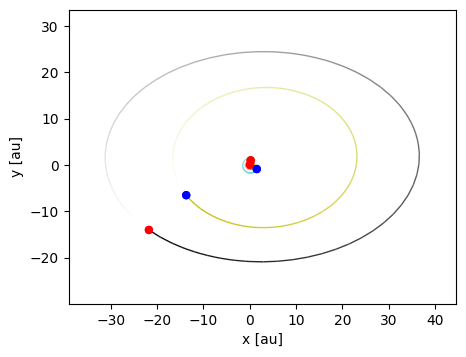

In [22]:
sim.status()
op2 = rebound.OrbitPlot(sim, color=True, unitlabel="[au]", )
op2.primary.set_color("orange")
op2.particles.set_color(["red", "blue"])

fig = op.fig
for i in range(nframe):
    op.sim.integrate(sim.t + framestep*2) # timestep the sim
    display.display(plt.gcf())          # start to...
    display.clear_output(wait=True)     # ...clean up old plot
    op.update() 

(-40.0, 40.0)

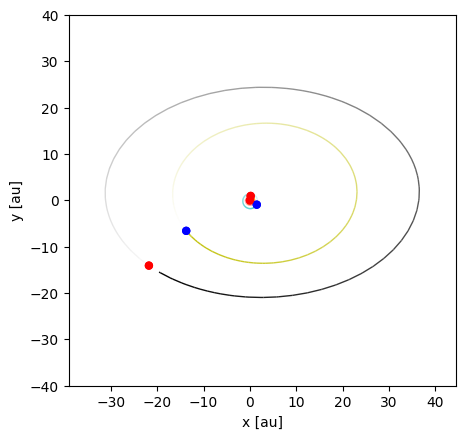

In [23]:
new_sim = rebound.Simulation('start.bin')


op2 = rebound.OrbitPlot(new_sim, color=True, unitlabel="[au]", )
op2.primary.set_color("orange")
op2.particles.set_color(["red", "blue"])

ax = plt.gca()
ax.set_aspect('equal')
ax.set_ylim(-40, 40)

In [14]:
new_sim.dt = 0.5
new_sim.integrate(1e3)
new_sim.move_to_com
new_sim.status()

---------------------------------
REBOUND version:     	4.4.6
REBOUND built on:    	Dec 30 2024 23:42:23
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	1.0000000000000000e+03
Current timestep:    	3.566788
---------------------------------
<rebound.particle.Particle object at 0x7f8a541b7140, m=0.76 x=-5.013313071490711 y=4.8138260671550785 z=-4.35908553987228 vx=-0.0035427367905807375 vy=0.008079101238619747 vz=-0.00738872836911749>
<rebound.particle.Particle object at 0x7f8a541b7240, m=0.002862797244 x=12.948200099620882 y=-4.395940123908118 z=3.2045745925405518 vx=-0.7776837884178003 vy=-0.622128670562334 vz=0.5275567389623294>
<rebound.particle.Particle object at 0x7f8a541b7140, m=0.001908531496 x=18.26686411361739 y=25.23855903675076 z=-26.81292780870953 vx=0.6610401830843962 vy=-0.32447942537852137 vz=0.36917964529812886>
---------------------------------
The following fields have non-default values:
t:
< 0.000000e+00
---
> 1.000000e+03
G:
< 1.000000e+00

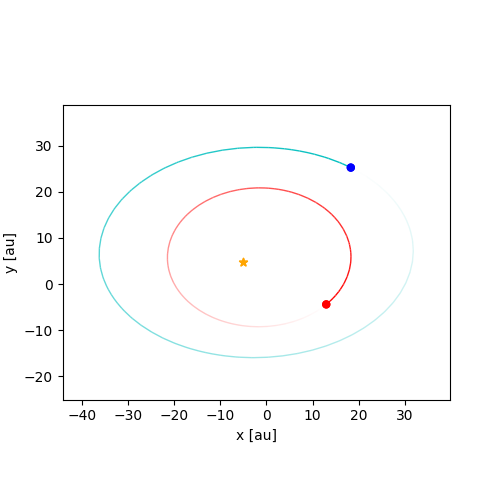

In [15]:
op2 = rebound.OrbitPlot(new_sim, color=True, unitlabel="[au]", )
op2.primary.set_color("orange")
op2.particles.set_color(["red", "blue"])
plt.show()

In [17]:
print(new_sim.orbits())
print(initial_conditions)

[<rebound.Orbit instance, a=19.923065425557578 e=0.18469893932360915 inc=2.4439723614930515 Omega=-0.010349324107634474 omega=2.768312171149253 f=4.0927198983393245>, <rebound.Orbit instance, a=34.158420654897036 e=0.12011553131454758 inc=2.303351658749527 Omega=0.010115818835511414 omega=2.3028544817759737 f=3.0684890605072193>]
  Particles  a (au)     e  omega(deg)  i (deg)  Omega (deg)   P (yr)
0  PDS 70 b    20.0  0.19       148.0    140.0        148.0  102.407
1  PDS 70 c    34.0  0.11       136.0    132.0        136.0  226.705


# Animations for presentation

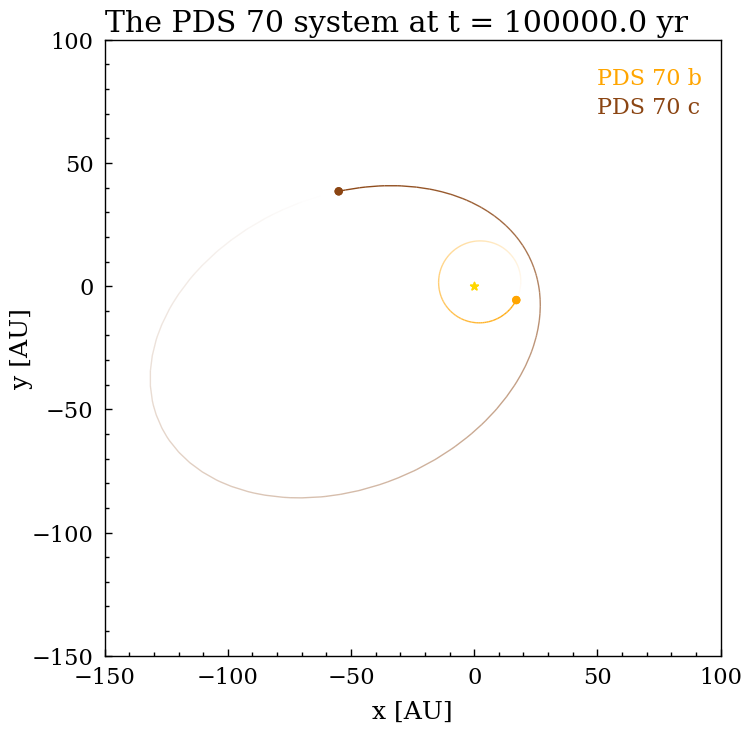

In [1]:
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt 
import rebound 
from matplotlib.animation import FuncAnimation
from plotting_params import use_my_style
use_my_style()


jtos = const.M_jup / const.M_sun

sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

sim.add(m = 0.967, hash='star')

m_b = 3
m_c = 2
sim.add(m = m_b * jtos, a = 20.8, e = 0.17, 
        omega = np.radians(161), inc = np.radians(131-128.3),
        Omega = np.radians(169.7), hash='pb', f=3.1)
sim.add(m = m_c * jtos, a = 34.3, e = 0.037, omega = np.radians(53), Omega= np.radians(161.7),
        inc = np.radians(130.5-128.3), hash='pc', f=4.89)

sim.dt = 0.1

sim.save_to_file('animation_archive.bin')

sim.move_to_com()


fig = plt.figure(figsize=(8,8))

fig.subplots_adjust(
    left=0.18,    # ← increase this
    right=0.95,
    bottom=0.08,
    top=0.95
)

ax = plt.subplot(111)
ax.set_xlabel('x [au]')
ax.set_ylabel('y [au]')
ax.set_aspect('equal')

def update(i):
    ax.clear()
    sim.integrate(100000 + i*5)
    op = rebound.OrbitPlot(sim, fig=fig, ax = ax, xlim = (-150, 100), ylim= (-150, 100), color=['orange', 'saddlebrown'])
    op.primary.set_color("gold")
    op.particles.set_color(["orange", "saddlebrown"])
    ax.set_title(f'The PDS 70 system at t = {sim.t} yr', loc='left')
    ax.text(x = 50, y = 82, s='PDS 70 b', color='orange', fontsize=16)
    ax.text(x = 50, y = 70, s='PDS 70 c', color='saddlebrown', fontsize=16)
    ax.set_xlabel('x [AU]')
    ax.set_ylabel('y [AU]', labelpad=-1)
    return op


ani = FuncAnimation(fig, update, frames=100, interval=50, blit=False)

ani.save('test_animation_crazy.gif', writer='pillow', fps = 10)

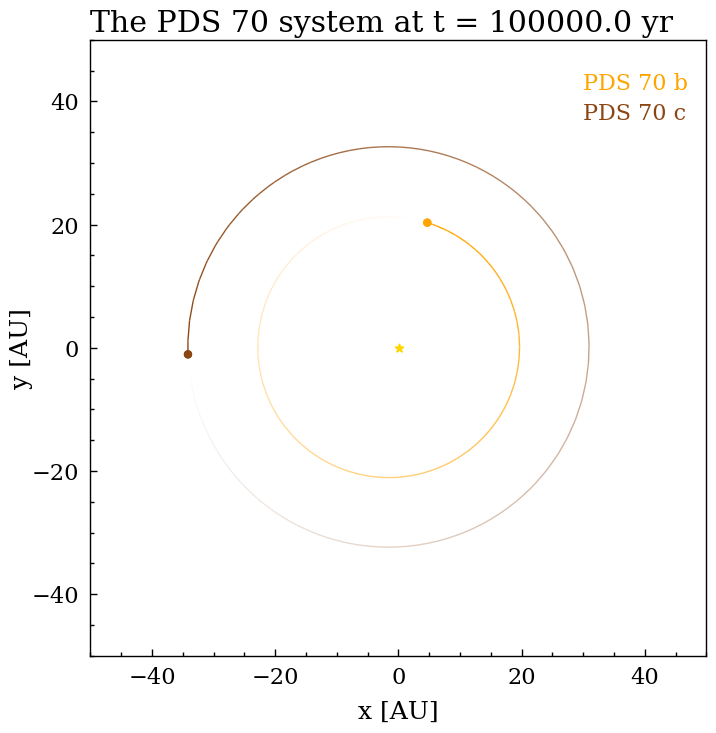

In [2]:

jtos = const.M_jup / const.M_sun

sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

sim.add(m = 0.967, hash='star')

m_b = 3
m_c = 2
sim.add(m = m_b * jtos, a = 20.8, e = 0.17, 
        omega = np.radians(161), inc = np.radians(131-128.3),
        Omega = np.radians(169.7), hash='pb', f=0)
sim.add(m = m_c * jtos, a = 34.3, e = 0.037, omega = np.radians(53), Omega= np.radians(161.7),
        inc = np.radians(130.5-128.3), hash='pc', f=0)

sim.dt = 0.1

sim.save_to_file('animation_archive_2.bin')

sim.move_to_com()


fig = plt.figure(figsize=(8,8))

fig.subplots_adjust(
    left=0.18,    # ← increase this
    right=0.95,
    bottom=0.08,
    top=0.95
)

ax = plt.subplot(111)
ax.set_xlabel('x [au]')
ax.set_ylabel('y [au]')
ax.set_aspect('equal')

def update(i):
    ax.clear()
    sim.integrate(100000 + i*5)
    op = rebound.OrbitPlot(sim, fig=fig, ax = ax, xlim = (-50, 50), ylim= (-50, 50), color=['orange', 'saddlebrown'])
    op.primary.set_color("gold")
    op.particles.set_color(["orange", "saddlebrown"])
    ax.set_title(f'The PDS 70 system at t = {sim.t} yr', loc='left')
    ax.text(x = 30, y = 42, s='PDS 70 b', color='orange', fontsize=16)
    ax.text(x = 30, y = 37, s='PDS 70 c', color='saddlebrown', fontsize=16)
    ax.set_xlabel('x [AU]')
    ax.set_ylabel('y [AU]', labelpad=-1)
    return op


ani = FuncAnimation(fig, update, frames=100, interval=50, blit=False)

ani.save('test_animation_calm.gif', writer='pillow', fps = 10)

In [35]:
sim.orbits()

[<rebound.Orbit instance, a=16.44652750194934 e=0.4584906839531498 inc=0.046844654856228865 Omega=2.9666554200234883 omega=2.5005901631077734 f=3.099313179413181>,
 <rebound.Orbit instance, a=98.887225757736 e=0.6913069790016122 inc=0.04017699819969139 Omega=2.849013835340153 omega=5.25342951833367 f=4.898017784242986>]

In [23]:
2**(2/3)

1.5874010519681994

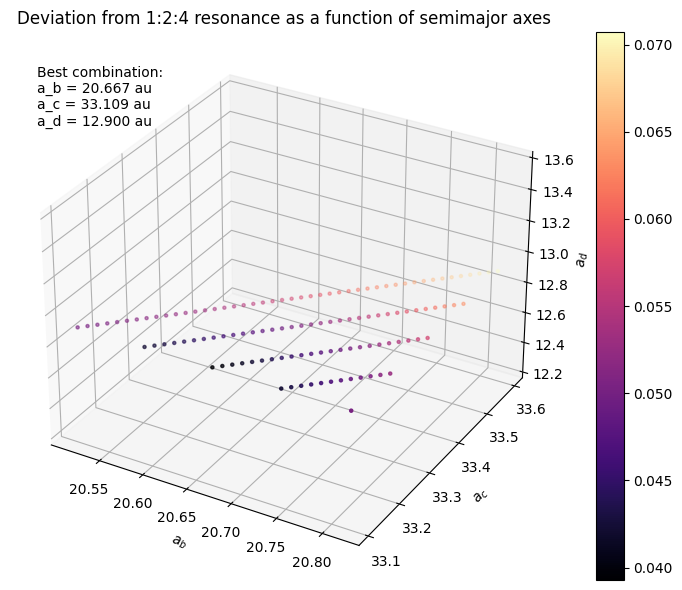

In [14]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt 


a_d = np.linspace(10.7-2.3, 10.7+2.2, 10)
a_b = np.linspace(21.1-1.0, 21.1+0.6, 100)
a_c = np.linspace(35.3-2.2, 35.3+1.0, 100)

valid_ab = []
valid_ac = []
valid_ad = []
dev = []

Pmin, Pmax = 1.95, 2.05

for ad in a_d:
    for P in np.linspace(Pmin, Pmax, 100):
        ab = ad * P**(2/3)

        if ab < np.min(a_b) or ab > np.max(a_b):
            continue
        
        for P2 in np.linspace(Pmin, Pmax, 10):
            ac = ab * P2**(2/3)

            if np.min(a_c) < ac < np.max(a_c):
                valid_ab.append(ab)
                valid_ac.append(ac)
                valid_ad.append(ad)
                dev.append(np.sqrt((P - 2)**2 + (P2 - 2)**2))

best_arg = np.argmin(dev)
best_ab, best_ac, best_ad = valid_ab[best_arg], valid_ac[best_arg], valid_ad[best_arg]

text =    r"Best combination:" + "\n" + \
          rf"a_b = {best_ab:.3f} au" + "\n" + \
          rf"a_c = {best_ac:.3f} au" + "\n" + \
          rf"a_d = {best_ad:.3f} au"

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(valid_ab, valid_ac, valid_ad, c=dev, cmap='magma', s=5)
ax.text2D(0.05, 0.83, text, transform=ax.transAxes)
fig.colorbar(sc)
ax.set_xlabel('$a_b$')
ax.set_ylabel('$a_c$')
ax.set_zlabel('$a_d$')
ax.set_title('Deviation from 1:2:4 resonance as a function of semimajor axes')
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import rebound
from joblib import Parallel, delayed
from astropy import constants as const

def run_simulation(iteration):
        
        period_ratios = np.zeros((2,))
        apohelions = np.zeros((3,))

        phases_i = np.zeros((3,))

        sim = rebound.Simulation()
        sim.units = ['msun', 'yr', 'AU']

        a_b, a_c, a_d = 21.1, 35.3, 10.7
        e_b, e_c, e_d = 0.131, 0.033, 0.25
        i_b, i_c, i_d = 128.7, 128.5, 151
        w_b, w_c, w_d = 191.4, 63, 29
        Omega_b, Omega_c, Omega_d = 174.3, 159.8, 144
        m_b, m_c, m_d = 1, 3, 0.5

        jtos = const.M_jup / const.M_sun

        sim.add(m = 0.965, hash='star')

        sim.add(m = m_d*jtos, a = a_d, e = e_d, omega=np.radians(w_d),
                f=np.random.rand()*2.*np.pi,
                inc=np.radians(i_d-128.3), Omega = np.radians(Omega_d), hash='pd')

        sim.add(m=m_b*jtos, a = a_b, e = e_b, omega=np.radians(w_b),
                #look into l parameter - also, isn't phase known?
                f=np.random.rand()*2.*np.pi,
                inc=np.radians(i_b-128.3), Omega = np.radians(Omega_b), hash='pb')

        sim.add(m=m_c*jtos, a=a_c, e=e_c, omega=np.radians(w_c),
                f=np.random.rand()*2.*np.pi,
                inc=np.radians(i_c-128.3), Omega=np.radians(Omega_c), hash='pc')   

        phases_i= [sim.particles['pd'].f, sim.particles['pb'].f, sim.particles['pc'].f]
        initial_orbits = sim.orbits()
        print(f' sim {iteration} phases: {phases_i}')
        sim.move_to_com()

        print(f'integrating sim {iteration}')
        sim.integrate(5e6)
        # op = rebound.OrbitPlot(sim, color=True, unitlabel='[au]')
        # op.primary.set_color("orange")
        # op.particles.set_color(["red", "turquoise", 'magenta'])

        for p,i,numb in zip(sim.particles[1:], ['d', 'b', 'c'], [0,1,2]):
                apohelions[numb] = p.a*(1+p.e)

        print(f'apohelions of sim {iteration}:', apohelions)                

        a_dd, a_bb, a_cc = [p.a for p in sim.particles[1:]]

        ratio_1 = (a_bb/a_dd) * 2**(2/3) 
        ratio_2 = (a_cc/a_bb) * 2**(2/3)
        init_rat_1 = (a_b/a_d) * 2**(2/3) 
        init_rat_2 = (a_c/a_b) * 2**(2/3) 
        print(f'The period ratio between the planets are {ratio_1:.3f} and {ratio_2:.3f}')
        print(f'The initial period ratios were {init_rat_1:.3f} and {init_rat_2:.3f} ')

        period_ratios[:] = ratio_1, ratio_2

        if apohelions[2] >= 40 and apohelions[0] < 40 and np.all(apohelions<= 87):
                return phases_i, period_ratios, initial_orbits
        else:
                return 'No valid phases'


results = Parallel(n_jobs=50)(delayed(run_simulation)(i) for i in range(50))


 sim 6 phases: [5.6563206329533475, 5.9430304321655285, 5.576184744681898]
integrating sim 6
 sim 4 phases: [0.26480885466712323, 3.309454622189074, 3.594203249184175]
integrating sim 4
 sim 5 phases: [4.316367077179988, 2.707798247064563, 4.377033350390066]
integrating sim 5
 sim 0 phases: [3.950888664616903, 5.710958889336155, 1.3533851934172105]
integrating sim 0
 sim 1 phases: [0.7956301005676671, 5.138522838397424, 3.563653696431412]
integrating sim 1
 sim 31 phases: [5.210923420691286, 4.656005675348435, 2.8447931948983523]
integrating sim 31
 sim 34 phases: [4.747942425996502, 3.690736098637066, 4.617395672342816]
integrating sim 34
 sim 35 phases: [1.7840787616792149, 1.8680497339158517, 0.7073693921076565]
integrating sim 35
 sim 37 phases: [3.4525613880559676, 5.449736310445218, 4.244456208746791]
integrating sim 37
 sim 9 phases: [5.360416895555581, 4.389292336918526, 3.9807866909828533]
integrating sim 9
 sim 14 phases: [1.456211753620945, 3.4427321745269452, 4.944648636335

In [2]:
results

['No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 ([5.360416895555581, 4.389292336918526, 3.9807866909828533],
  array([5.14917821, 2.54005691]),
  [<rebound.Orbit instance, a=10.699999999999996 e=0.2499999999999999 inc=0.39618974020271247 Omega=2.5132741228718345 omega=0.506145483078356 f=5.360416895555581>,
   <rebound.Orbit instance, a=21.100000000000016 e=0.13099999999999987 inc=0.006981317007983947 Omega=3.042108886226117 omega=3.3405601883171423 f=4.389292336918526>,
   <rebound.Orbit instance, a=35.29999999999996 e=0.03300000000000056 inc=0.003490658503985382 Omega=2.789036144686939 omega=1.0995574287564471 f=3.9807866909828533>]),
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 'No valid phases',
 '

<rebound.particle.Particle object at 0x7f87a8841640, m=0.965 x=-0.23255324601564853 y=0.23668253921029542 z=-0.023582321924699477 vx=-0.012096007367625238 vy=0.006918632095860572 vz=-0.006666129624625827>


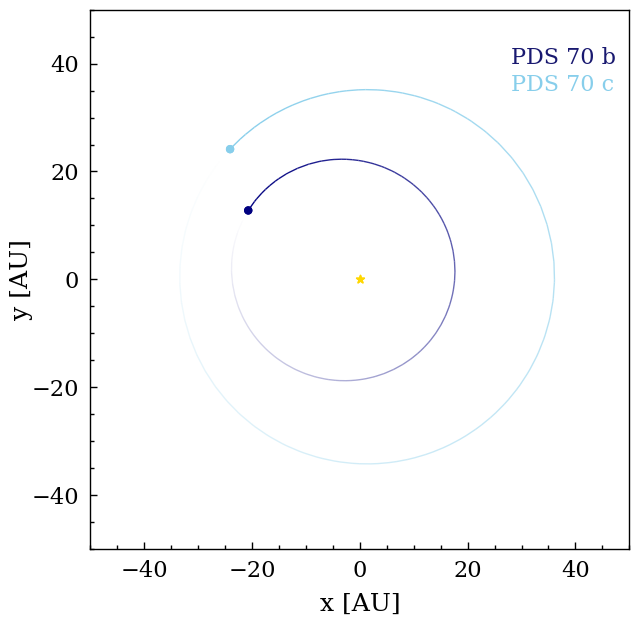

In [ ]:
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt 
import rebound 
from matplotlib.animation import FuncAnimation
from plotting_params import use_my_style
use_my_style()


jtos = const.M_jup / const.M_sun

sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

sim.add(m = 0.967, hash='star')

m_b = 3
m_c = 2
sim.add(m = m_b * jtos, a = 20.8, e = 0.17, 
        omega = np.radians(161), inc = np.radians(131-128.3),
        Omega = np.radians(169.7), hash='pb', f=3.1)
sim.add(m = m_c * jtos, a = 34.3, e = 0.037, omega = np.radians(53), Omega= np.radians(161.7),
        inc = np.radians(130.5-128.3), hash='pc', f=4.89)

for a in np.linspace(1, 87,10001):
        inc = np.random.uniform(-10, 10)
        sim.add(a=a, inc=np.radians(inc), f=np.random.rand()*2.*np.pi, e=0,
                primary=sim.particles[0])
xs = []
ys = []

for p in sim.particles:
    if p.m == 0:
        xs.append(p.x)
        ys.append(p.y)

sim.N_active = 3

fig, ax= plt.subplots(figsize=(7,7))

color_blue = [
    "#559fc7",  # medium
    "#031c2d",  # dark
]

color_pink = ["#841550FF", "#CAA1CD"]


op = rebound.OrbitPlot(sim, fig=fig, ax = ax, particles=['pb', 'pc'],
    primary=sim.particles['star'], xlim = (-50, 50), ylim= (-50, 50), color=['navy', 'skyblue'])
op.primary.set_color("gold")
op.particles.set_color(["navy", "skyblue"])
#ax.set_title(f'The PDS 70 system at t = {sim.t} yr')
ax.set_aspect('equal')
ax.text(x = 28, y = 40, s='PDS 70 b', color='midnightblue', fontsize=16)
ax.text(x = 28, y = 35, s='PDS 70 c', color='skyblue', fontsize=16)
ax.scatter(xs, ys, color='grey', alpha=0.3, s=2)
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]', labelpad=-1)
plt.savefig('plots/two_planets_orbit_blue_planetesimals.png')

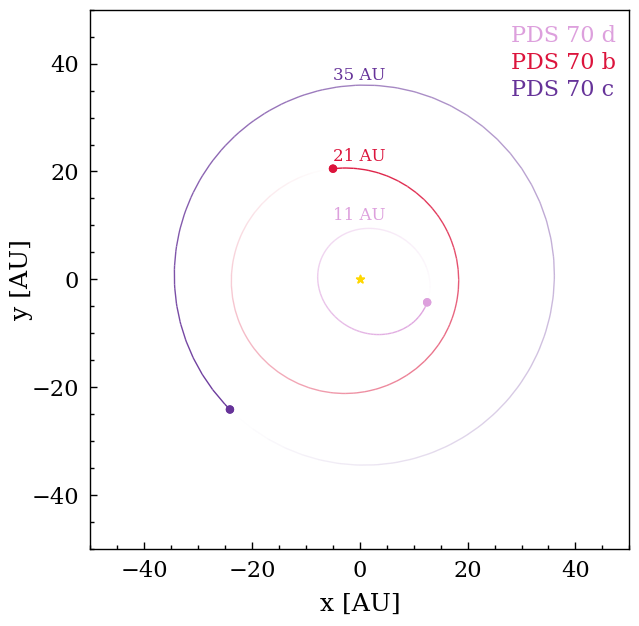

In [ ]:
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt 
import rebound 
from matplotlib.animation import FuncAnimation
from plotting_params import use_my_style
use_my_style()


jtos = const.M_jup / const.M_sun
a_b, a_c, a_d = 21.1, 35.3, 10.7
e_b, e_c, e_d = 0.131, 0.033, 0.25
w_b, w_c, w_d = 191.4, 63, 29
i_b, i_c, i_d = 128.7, 128.5, 151
Omega_b, Omega_c, Omega_d = 174.3, 159.8, 144
m_b, m_c, m_d = 0.7, 2.4, 0.4
sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']
dtor = np.pi /180
sim.add(m = 0.965, x=0, y= 0, z = 0, hash='star')
sim.add(m = m_d*jtos, a = a_d, e = e_d, f=np.random.rand()*2.*np.pi,
        inc = (i_d-128.3)*dtor, omega = w_d*dtor, Omega =  Omega_d*dtor, hash='pd')
sim.add(m = m_b*jtos, a = a_b, e = e_b, f=np.random.rand()*2.*np.pi,
        omega = w_b*dtor, inc = (i_b-128.3)*dtor, Omega = Omega_b*dtor, hash = 'pb')
sim.add(m = m_c*jtos, a = a_c, e = e_c, f=np.random.rand()*2.*np.pi,
        omega = w_c*dtor, inc = (i_c-128.3)*dtor, Omega = Omega_c*dtor, hash = 'pc')

# for a in np.linspace(1, 87,10001):
#         inc = np.random.uniform(-10, 10)
#         sim.add(a=a, inc=np.radians(inc), f=np.random.rand()*2.*np.pi, e=0,
#                 primary=sim.particles[0])
# xs = []
# ys = []

# for p in sim.particles:
#     if p.m == 0:
#         xs.append(p.x)
#         ys.append(p.y)

sim.N_active = 4

fig, ax= plt.subplots(figsize=(7,7))

op = rebound.OrbitPlot(sim, fig=fig, ax = ax, particles=['pb', 'pc', 'pd'],
    primary=sim.particles['star'], xlim = (-50, 50), ylim= (-50, 50), color=['crimson', 'rebeccapurple', 'plum'])
op.primary.set_color("gold")
op.particles.set_color(["crimson", "rebeccapurple", 'plum'])
#ax.set_title(f'The PDS 70 system at t = {sim.t} yr')
ax.set_aspect('equal')
ax.text(x = 28, y = 44, s='PDS 70 d', color='plum', fontsize=16)
ax.text(x = 28, y = 39, s='PDS 70 b', color='crimson', fontsize=16)
ax.text(x = 28, y = 34, s='PDS 70 c', color='rebeccapurple', fontsize=16)

ax.text(x = -5, y = 11, s=f'{a_d:.0f} AU', color='plum', fontsize=12)
ax.text(x = -5, y = 22, s=f'{a_b:.0f} AU', color='crimson', fontsize=12)
ax.text(x = -5, y = 37, s=f'{a_c:.0f} AU', color='rebeccapurple', fontsize=12)

# ax.scatter(xs, ys, color='grey', alpha=0.3, s=2)
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]', labelpad=-1)
plt.savefig('plots/three_planets_orbit_pink.png')

# Wang values example instability

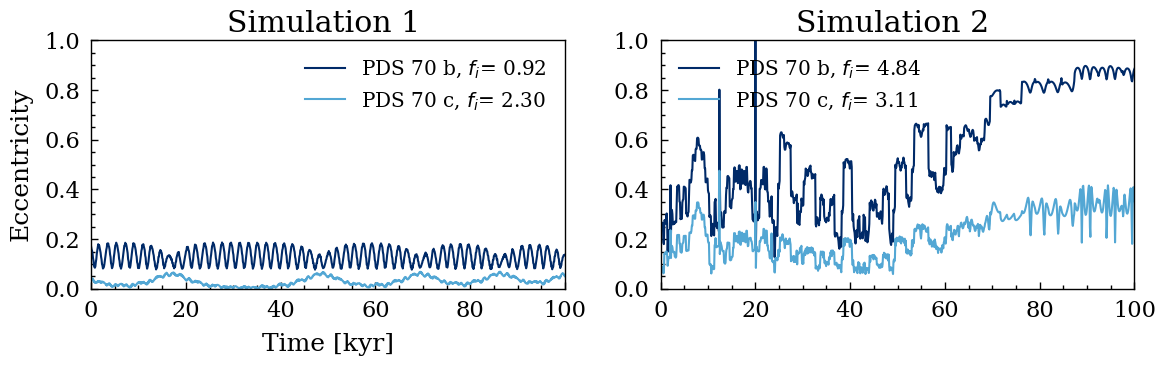

In [83]:
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt 
import rebound 
from matplotlib.animation import FuncAnimation
from plotting_params import use_my_style
use_my_style()


jtos = const.M_jup / const.M_sun


a_b, a_c = 20.8, 34.3
e_b, e_c = 0.17, 0.037
w_b, w_c = 161, 53
i_b, i_c = 131, 130.5
Omega_b, Omega_c = 169.7, 161.7
m_b, m_c = 3.2, 7.5
dtor = np.pi /180


sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

sim.add(m = 0.982, x=0, y= 0, z = 0, hash='star')

sim.add(m = m_b*jtos, a = a_b, e = e_b, f=0.921259941336461,
        omega = w_b*dtor, inc = (i_b-128.3)*dtor, Omega = Omega_b*dtor, hash = 'pb')

sim.add(m = m_c*jtos, a = a_c, e = e_c, f=2.29662932693939,
        omega = w_c*dtor, inc = (i_c-128.3)*dtor, Omega = Omega_c*dtor, hash = 'pc')
sim.N_active = 3

phases_1 = [sim.particles['pb'].f, sim.particles['pc'].f]

sim2 = rebound.Simulation()
sim2.units = ['msun', 'yr', 'AU']

sim2.add(m = 0.982, x=0, y= 0, z = 0, hash='star')

sim2.add(m = m_b*jtos, a = a_b, e = e_b, f=np.random.rand()*2.*np.pi,
        omega = w_b*dtor, inc = (i_b-128.3)*dtor, Omega = Omega_b*dtor, hash = 'pb')

sim2.add(m = m_c*jtos, a = a_c, e = e_c, f=np.random.rand()*2.*np.pi,
        omega = w_c*dtor, inc = (i_c-128.3)*dtor, Omega = Omega_c*dtor, hash = 'pc')
sim2.N_active = 3

phases_2 = [sim2.particles['pb'].f, sim2.particles['pc'].f]

fig, ax = plt.subplots(1, 2, figsize=(12,4))

color_blue = [
    "#53a7d4",  # medium
    "#002A68",  # dark
]

eccb_1 = []
eccc_1 = []

eccb_2, eccc_2 = [], []
ts = np.linspace(0, 100000, 1000)
for t in ts:
    sim.integrate(t)
    sim2.integrate(t)
    ecc_b, ecc_c  = sim.particles['pb'].e, sim.particles['pc'].e
    eccb_1.append(ecc_b)
    eccc_1.append(ecc_c)
    ecc_b2, ecc_c2  = sim2.particles['pb'].e, sim2.particles['pc'].e
    eccb_2.append(ecc_b2)
    eccc_2.append(ecc_c2)

ax[0].plot(ts/1000, eccb_1, color=color_blue[1], label=rf'PDS 70 b, $f_i$= {phases_1[0]:.2f}')
ax[0].plot(ts/1000, eccc_1, color=color_blue[0], label=rf'PDS 70 c, $f_i$= {phases_1[1]:.2f}')

ax[1].plot(ts/1000, eccb_2, color=color_blue[1], label=rf'PDS 70 b, $f_i$= {phases_2[0]:.2f}')
ax[1].plot(ts/1000, eccc_2, color=color_blue[0], label=rf'PDS 70 c, $f_i$= {phases_2[1]:.2f}')
ax[0].legend()
ax[0].set_ylim(0, 1)
ax[0].set_xlabel('Time [kyr]')
ax[0].set_ylabel('Eccentricity')
ax[1].legend()
ax[1].set_ylim(0, 1)
ax[0].set_title(f'Simulation 1 ')
ax[1].set_title(f'Simulation 2 ')
plt.tight_layout()
plt.savefig('plots/eccentricity_evolution.png')
plt.savefig('plots/eccentricity_evolution.pdf')


In [78]:
phases_1, phases_2

([0.9212599413364613, 2.2966293269393967],
 [5.504674070568707, 0.838973548694006])